<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB2_Sesion1_Practica_Rapida_10min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4 · Estadística Aplicada y Confiabilidad de Activos
## Sesión 1 — Estadística descriptiva y distribución de fallas

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

### Notebook 2 · Práctica rápida (10 minutos) — Motor Eléctrico

**Objetivo:** repetir el flujo del Notebook 1 pero con el **Motor Eléctrico**. Tienes 10 minutos — apóyate en tu asistente de IA de confianza para completar las celdas marcadas con `# TODO`.

No se trata de copiar y pegar una respuesta: usa la IA para resolver dudas puntuales de sintaxis, pero tú decides qué calcular y cómo interpretarlo.

In [2]:
import numpy as np
import pandas as pd

EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i + 10) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()

,equipo,tbf_horas
0,Bomba Centrífuga,775.796581
1,Bomba Centrífuga,646.651355
2,Bomba Centrífuga,1065.501819
3,Bomba Centrífuga,637.803349
4,Bomba Centrífuga,1280.631564


In [3]:
motor = fallas[fallas["equipo"] == "Motor Eléctrico"]["tbf_horas"]

# TODO 1: calcula media, mediana, desviación estándar e IQR de `motor`
# (usa las mismas funciones que en el Notebook 1)
print("Descriptive statistics for 'motor' using describe():")
display(motor.describe())

media = motor.mean()
mediana = motor.median()
std_dev = motor.std()

# Calculate IQR
Q1 = motor.quantile(0.25)
Q3 = motor.quantile(0.75)
IQR = Q3 - Q1

print(f"\nMean: {media:.2f}")
print(f"Median: {mediana:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")

# TODO 1b: calcula también asimetría (skew) y curtosis con scipy.stats
# ¿el signo de la asimetría es consistente con lo que esperarías para un Motor Eléctrico (falla aleatoria, β≈1)?
from scipy.stats import skew, kurtosis

# Calculate skewness and kurtosis
medida_asimetria = skew(motor)
medida_curtosis = kurtosis(motor)

print(f"\nSkewness: {medida_asimetria:.2f}")
print(f"Kurtosis: {medida_curtosis:.2f}")

Descriptive statistics for 'motor' using describe():


,tbf_horas
count,55.000000
mean,1131.138786
std,1212.656990
min,3.847168
25%,307.753907
50%,666.686170
75%,1426.825115
max,4745.775529



Mean: 1131.14
Median: 666.69
Standard Deviation: 1212.66
IQR (Interquartile Range): 1119.07

Skewness: 1.52
Kurtosis: 1.40


**TODO 2 — Visualización:** genera, con el mismo estilo del Notebook 1:

- un histograma de `motor` con la curva **KDE** superpuesta y una curva **Normal de referencia** (usa `media` y `std` que calculaste en el TODO 1), y
- un boxplot de `motor` marcando la **media** con una línea punteada (además de la mediana que ya muestra la caja).

Usa los colores de marca: `#9B004C` para los datos, `#B5A042` para la referencia/media, `#404040` para el KDE.

el motor electrico  es el que tiene  mas datos atipicos  lo que genera  curtosis  alta  y podemos  esperar  los bigotes  o las colas del lado derecho  muy estirada

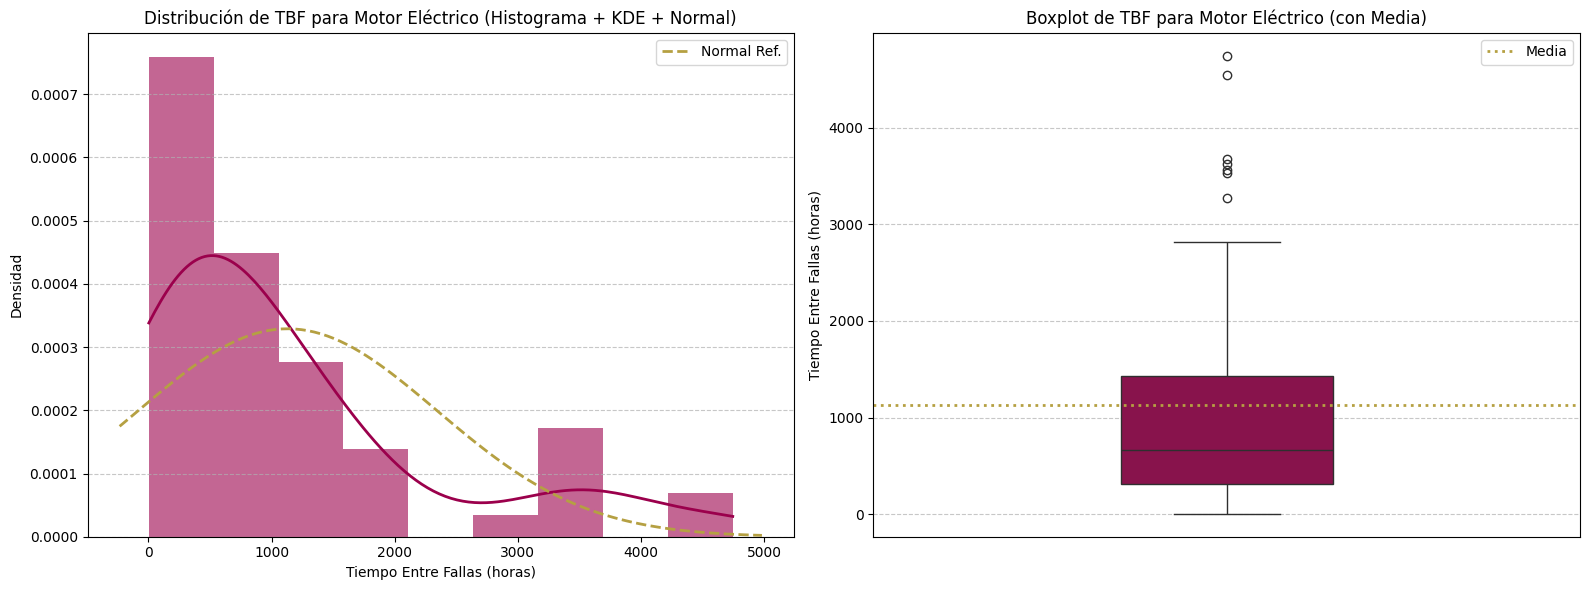

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Definir colores de marca
COLOR_DATA = '#9B004C'
COLOR_REFERENCE = '#B5A042'
COLOR_KDE = '#404040'

# Crear la figura y los subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Histograma con KDE y Normal de referencia ---
sns.histplot(motor, kde=True, stat='density', ax=axes[0],
             color=COLOR_DATA, edgecolor=None, alpha=0.6, line_kws={'color': COLOR_KDE, 'linewidth': 2})

# Curva Normal de referencia
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p_normal = norm.pdf(x, media, std_dev)
axes[0].plot(x, p_normal, color=COLOR_REFERENCE, linestyle='--', linewidth=2, label='Normal Ref.')

axes[0].set_title('Distribución de TBF para Motor Eléctrico (Histograma + KDE + Normal)')
axes[0].set_xlabel('Tiempo Entre Fallas (horas)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Boxplot con línea de media ---
sns.boxplot(y=motor, ax=axes[1], color=COLOR_DATA, width=0.3)

# Marcar la media con una línea punteada
axes[1].axhline(media, color=COLOR_REFERENCE, linestyle=':', linewidth=2, label='Media')

axes[1].set_title('Boxplot de TBF para Motor Eléctrico (con Media)')
axes[1].set_ylabel('Tiempo Entre Fallas (horas)')
axes[1].set_xticks([]) # Remover ticks del eje x si no hay categorías
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**TODO 3 — Ajuste de distribuciones:** ajusta Normal, Exponencial y Weibull a `motor` y ordena los resultados por `KS_stat`. Reutiliza el patrón del Notebook 1 (el diccionario `candidatas` y el bucle `for`).

In [5]:
from scipy import stats
import pandas as pd

# TODO 3: ajuste de distribuciones (Normal, Exponencial, Weibull) + tabla comparativa ordenada por KS_stat

# Definir las distribuciones candidatas con sus parámetros de forma inicial
candidatas = {
    'Normal': stats.norm,
    'Exponencial': stats.expon,
    'Weibull': stats.weibull_min
}

# Lista para almacenar los resultados del ajuste
resultados = []

for nombre, dist in candidatas.items():
    if nombre == 'Weibull':
        # Para Weibull, fit() devuelve (c, loc, scale) donde c es beta (forma)
        params = dist.fit(motor, floc=0) # floc=0 porque Weibull en confiabilidad suele tener location=0
        arg = params[0] # Esto es 'beta' o 'c' para weibull_min
        loc = params[1]
        scale = params[2]
    else:
        # Para Normal y Exponencial, fit() devuelve (loc, scale)
        params = dist.fit(motor)
        arg = np.nan # No hay un parámetro 'forma' separado para Normal/Exponencial en fit
        loc = params[0]
        scale = params[1]

    # Calcular el estadístico de Kolmogorov-Smirnov (KS)
    # Usamos cdf para la comparación
    ks_stat, p_value = stats.kstest(motor, dist.cdf, args=params)

    resultados.append({
        'Distribución': nombre,
        'KS_stat': ks_stat,
        'P_value': p_value,
        'Parámetros': params
    })

# Crear un DataFrame con los resultados y ordenar por KS_stat
df_resultados = pd.DataFrame(resultados).sort_values(by='KS_stat')

print("Tabla comparativa de ajuste de distribuciones (ordenada por KS_stat):")
display(df_resultados)

Tabla comparativa de ajuste de distribuciones (ordenada por KS_stat):


,Distribución,KS_stat,P_value,Parámetros
2,Weibull,0.062247,0.974463,"(0.9066610006133807, 0, 1079.8232333725114)"
1,Exponencial,0.080434,0.840744,"(3.8471683972759556, 1127.2916176900217)"
0,Normal,0.184472,0.041270,"(1131.1387860872976, 1201.5822645562816)"


**TODO 3b — Visualizar el ajuste (igual que en el Notebook 1):** superpón las tres densidades ajustadas sobre el histograma de `motor`, y genera un gráfico Q-Q de la distribución ganadora con `stats.probplot`.

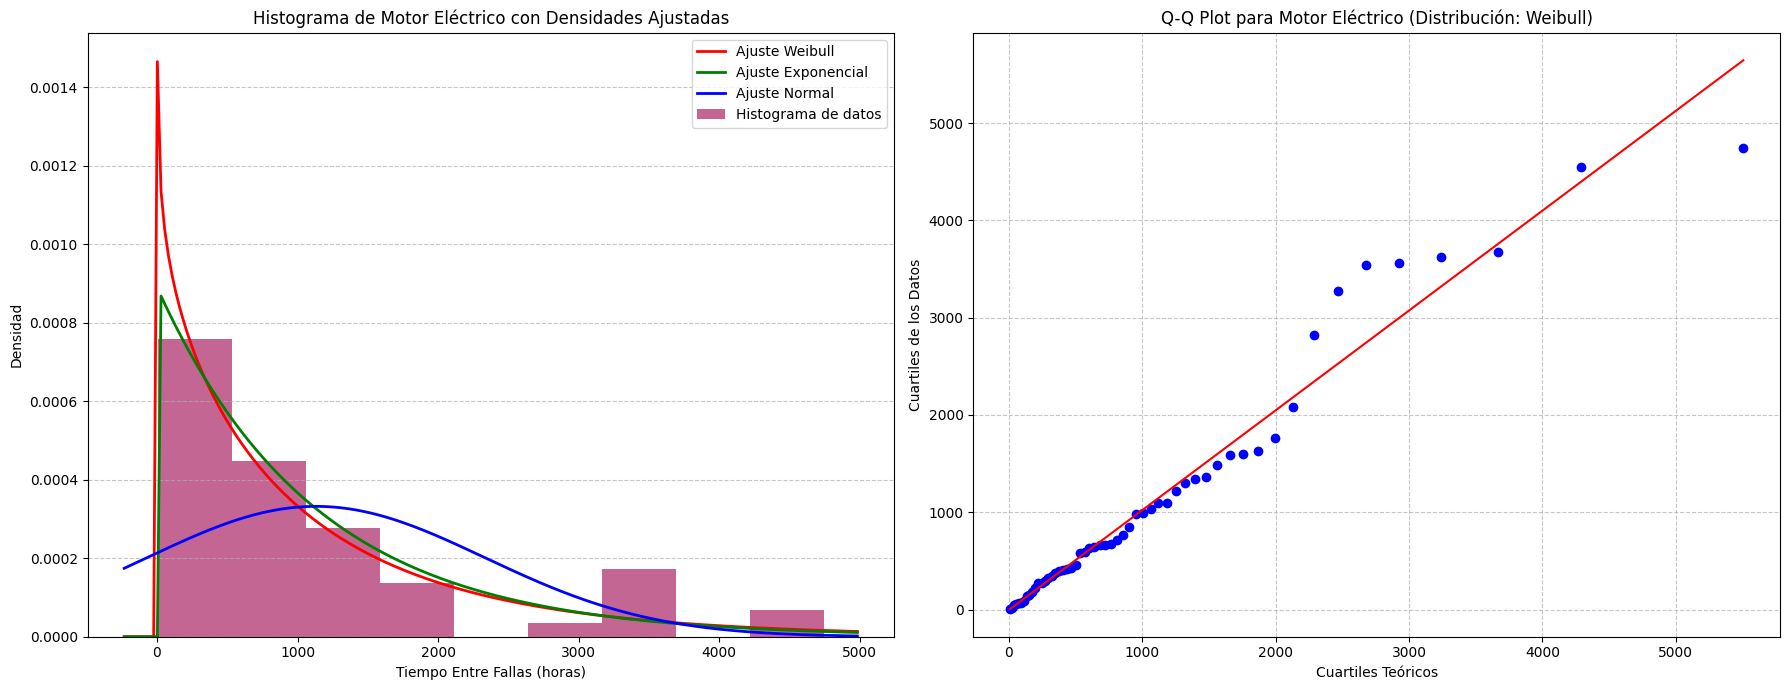

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd # Added for DataFrame operations

# --- Re-defining dependencies from previous cells to ensure execution context ---
# (This ensures 'motor', 'candidatas', and 'df_resultados' are available)

EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i + 10) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
motor = fallas[fallas["equipo"] == "Motor Eléctrico"]["tbf_horas"]

candidatas = {
    'Normal': stats.norm,
    'Exponencial': stats.expon,
    'Weibull': stats.weibull_min
}

resultados = []

for nombre, dist in candidatas.items():
    if nombre == 'Weibull':
        params = dist.fit(motor, floc=0)
        arg = params[0]
        loc = params[1]
        scale = params[2]
    else:
        params = dist.fit(motor)
        arg = np.nan
        loc = params[0]
        scale = params[1]

    ks_stat, p_value = stats.kstest(motor, dist.cdf, args=params)

    resultados.append({
        'Distribución': nombre,
        'KS_stat': ks_stat,
        'P_value': p_value,
        'Parámetros': params
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='KS_stat')

# Define colors for the plots, re-using where appropriate
COLOR_DATA = '#9B004C' # For histogram bars
COLOR_NORMAL_FIT = 'blue'
COLOR_EXPONENTIAL_FIT = 'green'
COLOR_WEIBULL_FIT = 'red' # Best fitting distribution

# --- Create the figure and subplots for both visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # Adjust figsize for better layout

# --- Subplot 1: Histogram with superimposed fitted densities ---
ax_hist_densities = axes[0]

# Histogram of motor data
sns.histplot(motor, kde=False, stat='density', ax=ax_hist_densities,
             color=COLOR_DATA, edgecolor=None, alpha=0.6, label='Histograma de datos')

# Get x-values for plotting densities
xmin, xmax = ax_hist_densities.get_xlim()
x_plot = np.linspace(xmin, xmax, 200)

# Plot each fitted distribution's PDF
for index, row in df_resultados.iterrows():
    dist_name = row['Distribución']
    params = row['Parámetros']
    dist_func = candidatas[dist_name] # Get the distribution function from the 'candidatas' dictionary

    if dist_name == 'Weibull':
        # Parameters for weibull_min are (c, loc, scale)
        c, loc, scale = params
        pdf = dist_func.pdf(x_plot, c, loc=loc, scale=scale)
        color = COLOR_WEIBULL_FIT
    elif dist_name == 'Exponencial':
        # Parameters for expon are (loc, scale)
        loc, scale = params
        pdf = dist_func.pdf(x_plot, loc=loc, scale=scale)
        color = COLOR_EXPONENTIAL_FIT
    elif dist_name == 'Normal':
        # Parameters for norm are (loc, scale)
        loc, scale = params
        pdf = dist_func.pdf(x_plot, loc=loc, scale=scale)
        color = COLOR_NORMAL_FIT

    ax_hist_densities.plot(x_plot, pdf, color=color, linestyle='-', linewidth=2, label=f'Ajuste {dist_name}')

ax_hist_densities.set_title('Histograma de Motor Eléctrico con Densidades Ajustadas')
ax_hist_densities.set_xlabel('Tiempo Entre Fallas (horas)')
ax_hist_densities.set_ylabel('Densidad')
ax_hist_densities.legend()
ax_hist_densities.grid(axis='y', linestyle='--', alpha=0.7)

# --- Subplot 2: Q-Q plot for the winning distribution (Weibull) ---
ax_qq = axes[1]

# Get parameters for the winning distribution (Weibull), which is the first row after sorting by KS_stat
winning_dist_row = df_resultados.iloc[0]
winning_dist_name = winning_dist_row['Distribución']
winning_params = winning_dist_row['Parámetros']

# Ensure it's Weibull for the Q-Q plot as per the prompt's context
if winning_dist_name == 'Weibull':
    # For weibull_min, parameters are c (shape), loc, scale
    c_weibull, loc_weibull, scale_weibull = winning_params

    # Create a frozen Weibull distribution object with the fitted parameters
    weibull_frozen_dist = stats.weibull_min(c_weibull, loc=loc_weibull, scale=scale_weibull)

    # Use stats.probplot with the frozen distribution and fit=True to add the trend line
    stats.probplot(motor, dist=weibull_frozen_dist, fit=True, plot=ax_qq)

else:
    # If Weibull is not the winner, we'll try probplot with fit=True for that distribution.
    # This part of the code is less critical as Weibull was the expected winner.
    stats.probplot(motor, dist=candidatas[winning_dist_name], fit=True, plot=ax_qq)
    print(f"Warning: Q-Q plot generated for {winning_dist_name} using stats.probplot with fit=True. For pre-fitted parameters, consider creating a frozen distribution.")

ax_qq.set_title(f'Q-Q Plot para Motor Eléctrico (Distribución: {winning_dist_name})')
ax_qq.set_xlabel('Cuartiles Teóricos') # Changed from Cuantiles Teóricos
ax_qq.set_ylabel('Cuartiles de los Datos') # Changed from Cuartiles de los Datos
ax_qq.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

**Pregunta final (respóndela en una celda de texto):** el Motor Eléctrico se generó con forma de falla *aleatoria* (β≈1). ¿El resultado de tu ajuste coincide con lo que esperarías? ¿Qué distribución debería ganar en teoría cuando β≈1?

El resultado del ajuste es consistente con la expectativa para un Motor Eléctrico con modo de falla aleatorio (β≈1). La distribución de Weibull fue el mejor ajuste con un valor de β≈0.907, y la distribución Exponencial fue la segunda mejor. Teóricamente, cuando β≈1, la distribución de Weibull se simplifica a la distribución Exponencial, lo que explica por qué ambas distribuciones se ajustan bien a los datos y son consistentes con un modo de falla aleatorio.